(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(

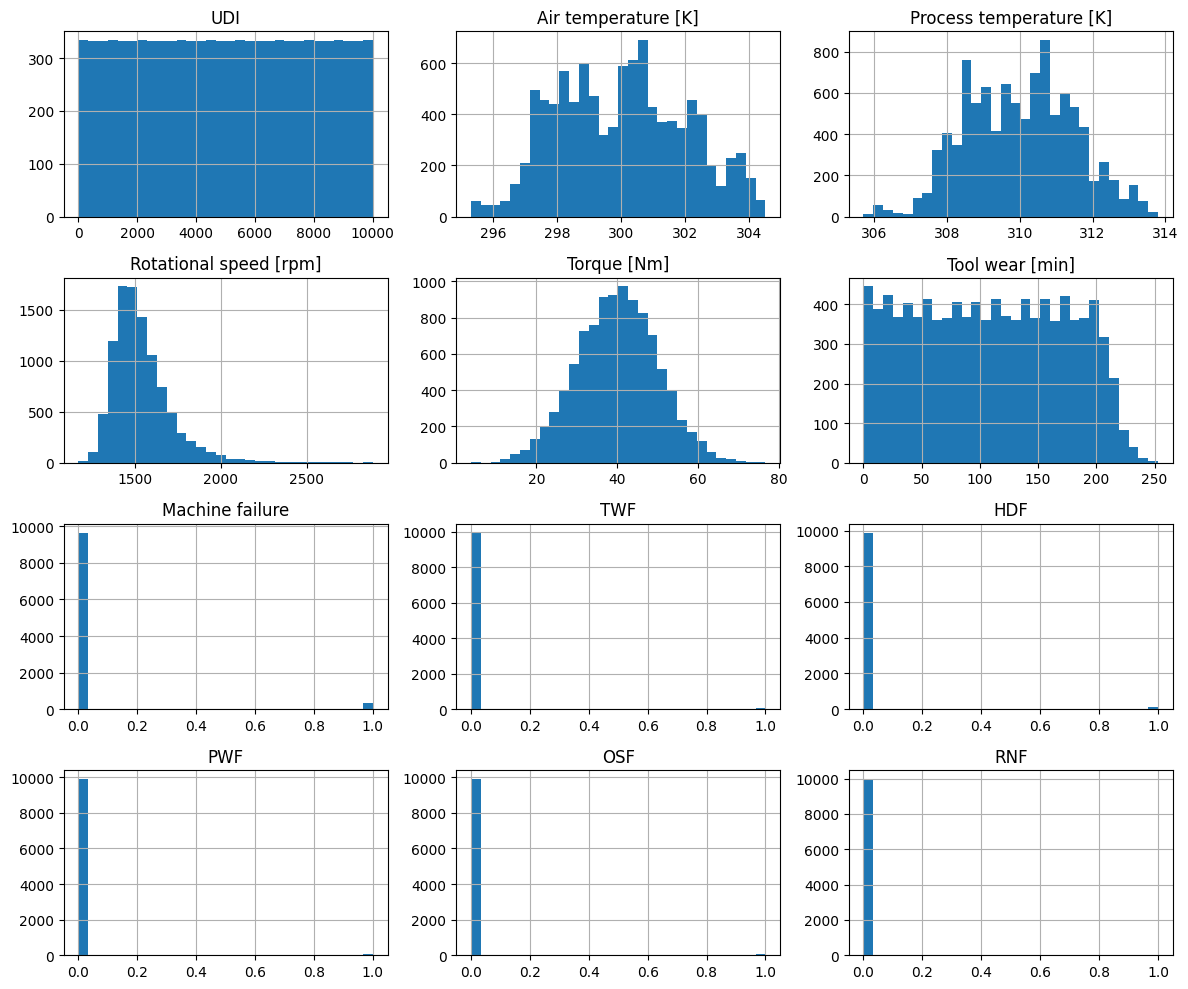

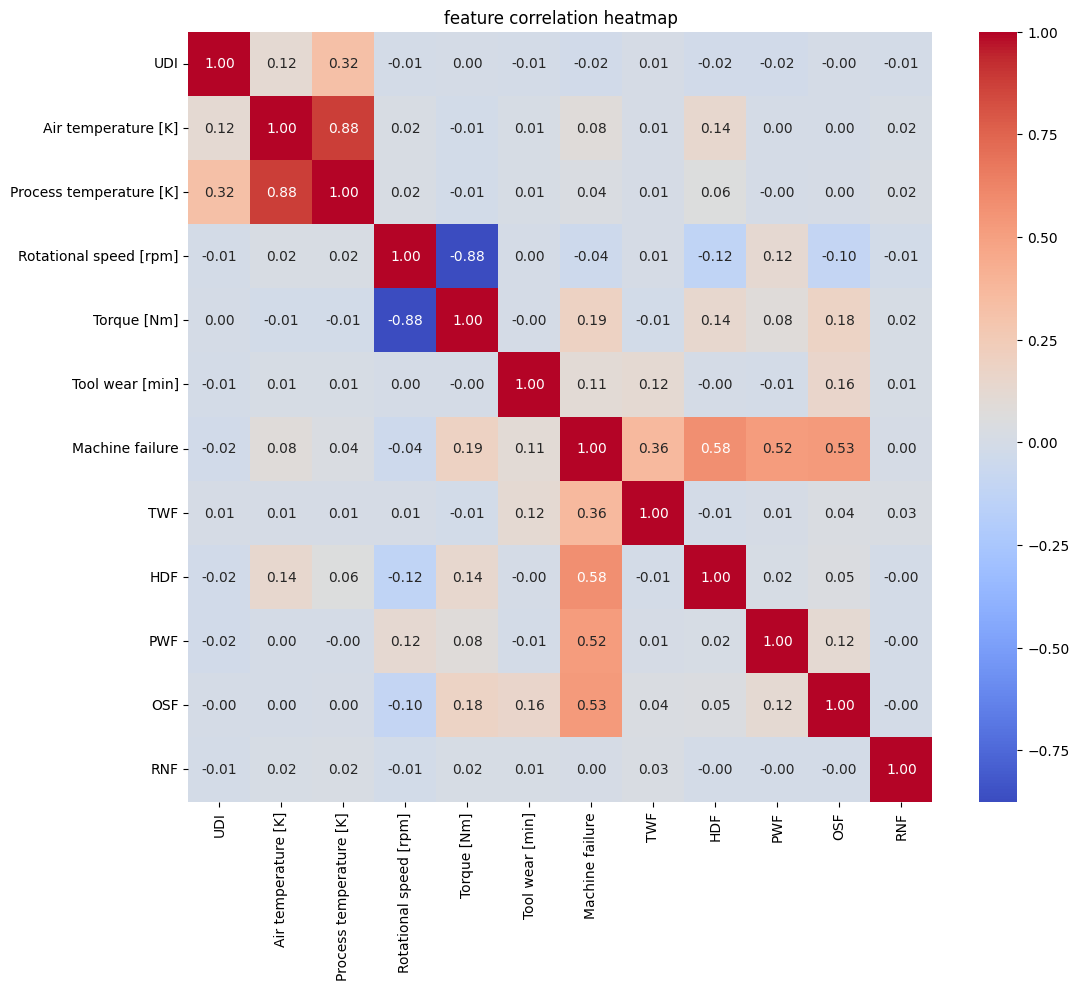

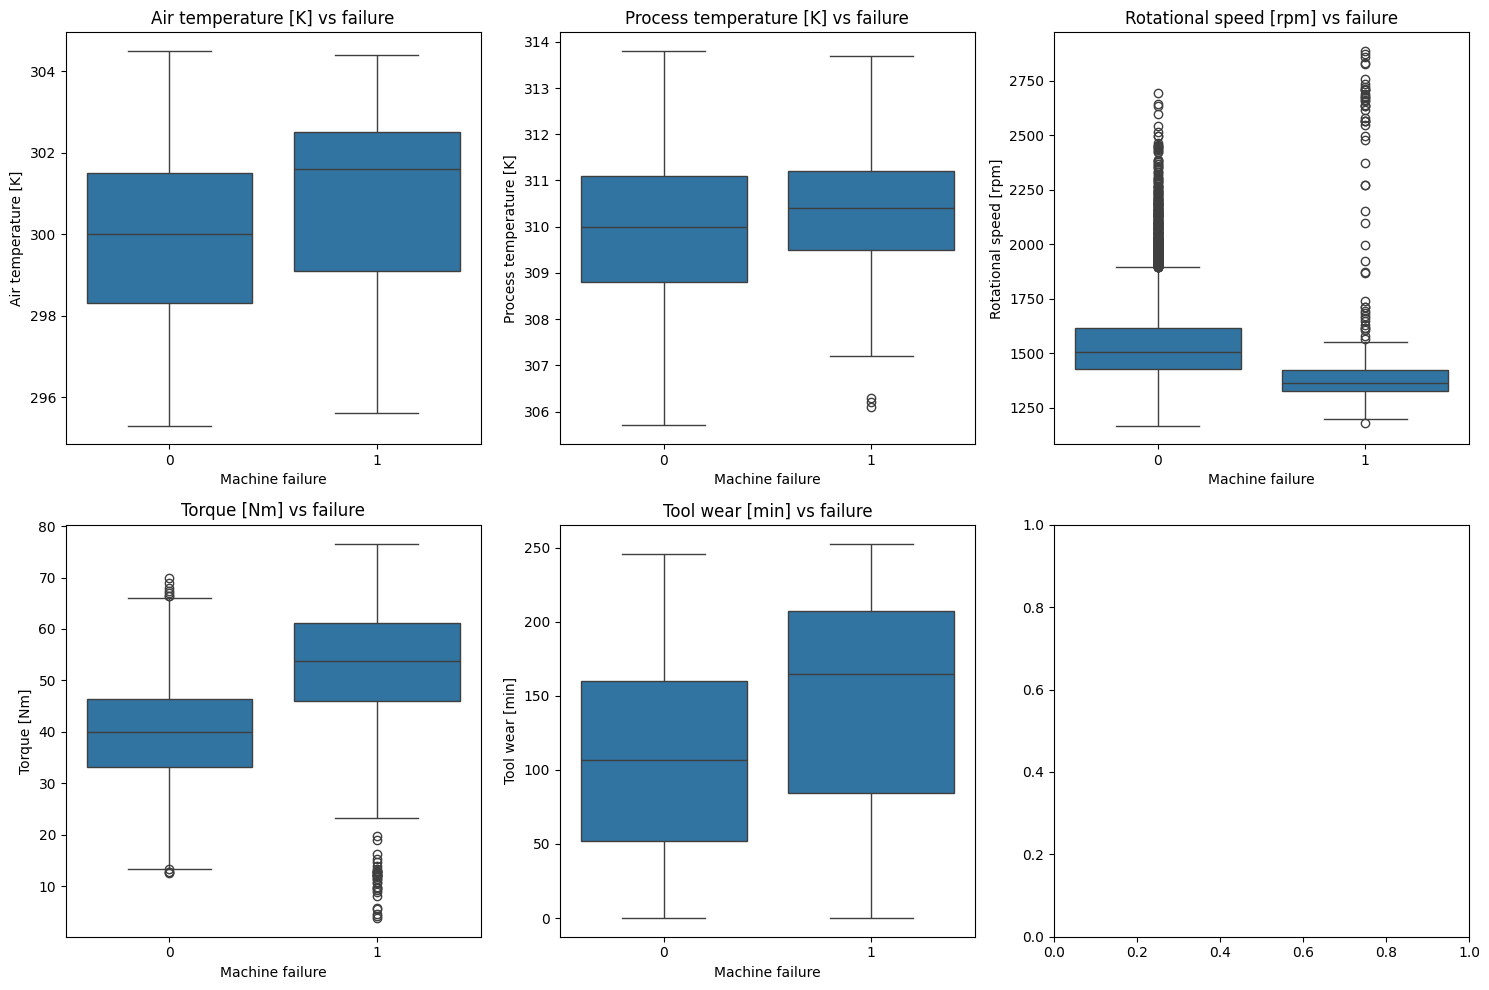

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai4i2020.csv')

#basic inspection of the data
print(df.shape) #rows and column
print(df.info()) # data types, missing values
print(df.describe()) # summary statistics
print(df.isnull().sum()) # check for missing values

#visualization of feature distributions
df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

#correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('feature correlation heatmap')
plt.show()

#boxplots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15,10))
for idx, col in enumerate(['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']):
    ax = axes[idx//3, idx%3]
    sns.boxplot(x= 'Machine failure', y=col,data=df, ax=ax)
    ax.set_title(f'{col} vs failure')
plt.tight_layout()
plt.show()

In [8]:
#drop UDI column and create new features on the interaction of torque with tool wear and rotational speed
df = df.dropna(subset=['UDI'])
df['torque_toolwear'] = df['Torque [Nm]'] * df['Tool wear [min]']
df['torque_rotationspeed'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

#removing outliers based on boxplot analysis
# Check for physically impossible values
print("Air temp range:", df['Air temperature [K]'].min(), "-", df['Air temperature [K]'].max())
print("Process temp range:", df['Process temperature [K]'].min(), "-", df['Process temperature [K]'].max())
print("Speed range:", df['Rotational speed [rpm]'].min(), "-", df['Rotational speed [rpm]'].max())
print("Torque range:", df['Torque [Nm]'].min(), "-", df['Torque [Nm]'].max())

# Expected ranges for a typical industrial motor:
# Air temp: 290-310 K (room temperature-ish)
# Process temp: 300-315 K (slightly above air)
# Speed: 1000-3000 rpm
# Torque: 0-80 Nm

# Remove only physically impossible values
df_clean = df[
    (df['Air temperature [K]'] > 250) & (df['Air temperature [K]'] < 350) &
    (df['Process temperature [K]'] > 250) & (df['Process temperature [K]'] < 350) &
    (df['Rotational speed [rpm]'] > 0) &
    (df['Torque [Nm]'] >= 0) & (df['Torque [Nm]'] < 100)
].copy()

print(f"Removed {len(df) - len(df_clean)} impossible rows")



Air temp range: 295.3 - 304.5
Process temp range: 305.7 - 313.8
Speed range: 1168 - 2886
Torque range: 3.8 - 76.6
Removed 0 impossible rows


In [9]:
#Data preprocessing for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define features and target
Features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'torque_toolwear', 'torque_rotationspeed']
Target = 'Machine failure'  

X = df_clean[Features]
y = df_clean[Target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
#logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(class_weight='balanced', random_state=42)

lr.fit(X_train_scaled, y_train)

y_lr_pred = lr.predict(X_test_scaled)
y_lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_lr_pred))
print("ROC AUC Score:\n", roc_auc_score(y_test, y_lr_proba))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.85      0.92      1932
           1       0.17      0.87      0.29        68

    accuracy                           0.85      2000
   macro avg       0.58      0.86      0.60      2000
weighted avg       0.97      0.85      0.90      2000

Confusion Matrix:
 [[1648  284]
 [   9   59]]
ROC AUC Score:
 0.9377968578735842


In [11]:
#Random Forest model
from sklearn.ensemble import RandomForestClassifier

Rr = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)
Rr.fit(X_train, y_train)

y_Rr_pred = Rr.predict(X_test)
y_Rr_proba = Rr.predict_proba(X_test)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_Rr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_Rr_pred))
print("ROC AUC Score:\n", roc_auc_score(y_test, y_Rr_proba))

#feature importance
importances = pd.DataFrame({'feature': Features, 'importance': Rr.feature_importances_
                            }).sort_values('importance', ascending=False)
print(importances)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.56      0.68        68

    accuracy                           0.98      2000
   macro avg       0.93      0.78      0.84      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
 [[1927    5]
 [  30   38]]
ROC AUC Score:
 0.9691115576665449
                   feature  importance
2   Rotational speed [rpm]    0.226953
6     torque_rotationspeed    0.201381
3              Torque [Nm]    0.168081
4          Tool wear [min]    0.135969
5          torque_toolwear    0.122276
0      Air temperature [K]    0.094571
1  Process temperature [K]    0.050770


In [13]:
import xgboost as xgb

X_train_cleaned = X_train.copy()
X_test_cleaned = X_test.copy()

X_train_cleaned.columns = X_train_cleaned.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test_cleaned.columns = X_test_cleaned.columns.str.replace(r'[\[\]<>]', '', regex=True)
xgb_model = xgb.XGBClassifier(scale_pos_weight=97, max_depth=5, n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_cleaned, y_train)
y_xgb_pred = xgb_model.predict(X_test_cleaned)
y_xgb_proba = xgb_model.predict_proba(X_test_cleaned)[:, 1]
print("Classification Report:\n", classification_report(y_test, y_xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_xgb_pred))
print("ROC AUC Score:\n", roc_auc_score(y_test, y_xgb_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.67      0.79      0.72        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
 [[1905   27]
 [  14   54]]
ROC AUC Score:
 0.9649327122153208


In [14]:
from sklearn.model_selection import RandomizedSearchCV
#finding best hyperparameters for xgboost using randomized search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10], # Note: xgboost uses 'min_child_weight' instead of 'min_samples_split'
    'min_samples_leaf': [1, 2, 4], # Note: xgboost uses 'min_child_weight' instead of 'min_samples_leaf'
}

search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid, n_iter=20 #20 combinations to try
                            , scoring='roc_auc', cv=5 #5-fold cross-validation
                            , n_jobs=-1 #use all available cores
                            , random_state=42)

search.fit(X_train_cleaned, y_train)
print("Best Hyperparameters:", search.best_params_)
print("Best ROC AUC Score from CV:", search.best_score_)
best_model = search.best_estimator_

c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [16:44:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 3}
Best ROC AUC Score from CV: 0.9818655308448573


In [15]:
import joblib
joblib.dump(best_model, 'predictive_maintenance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']